# **Problema 1 - Exemplo: Indústria de Laticínios**

O estudo foi realizado em uma Indústria de Laticínios situada na região da zona da mata mineira, que devido a sua localização atende os mercados dos estados do Rio de Janeiro, Minas Gerais e Espírito Santos.

A empresa tem um portfólio de produtos, em que produz diversas variedades como queijos, bebidas lácteas e leite fermentado.
Foi disponibilizado pela empresa o acesso aos bancos de dados históricos de venda de 2022 no intuito de analisar o comportamento da demanda e assim fazer a projeção desta para o ano de 2023.

$\qquad\qquad\qquad$Tabela 1: Laticínios vendidos (2022)
$\begin{array}{r|rrrrrrrrr}
Mês& Jan&Fev&Mar&Abril&Maio&Jun&Jul&Ago&Set&Out&Nov&Dez \\
\hline
Vendas &127846&110451&204905&134534&128241&118551&150315&159845&134929&117723&103158&96729\\
\end{array}$


Com base nas informações apresentadas na tabela acima, faça uma previsão para a venda de  laticínios para o ano de 2023, pelo Método dos Mínimos Quadrados Quadrático, com tendência sazonal.

# Roteiro:

a) Resolva o sistema pelo Método de Gauss com os valores da tabela acima;

b) Determine a equação da curva que melhor se ajuste aos pontos dados pelo MMQ;

c) Calcule o Índice Sazonal Mensal $\epsilon_{i}$ = Demanda real / Demanda prevista pelo MMQ, i = 1,. . . ,12;

d) Multiplique cada Índice Sazonal Mensal $\epsilon_{i}$ pelo valor encontrado pelo MMQ no mês i+12, i = 1, . . ,12;

###OBS:O problema deve ser resolvido com técnicas vistas em Cálculo Numérico.

$\qquad\qquad\qquad$Tabela 2: Laticínios vendidos (2023)
$\begin{array}{|c|c|c|c|c|c|c|c|c|c|c|c|c|}
\hline
Mês &jan&fev&mar&abr&maio&jun&jul&ago&set&out&nov&dez\\
\hline
Vendas(a) &127846&110451&204905&134534&128241&118551&150315&159845&134929&117723&103158&96729\\
\hline
MMQ(2022) (b) &&&&&&&&&&&&\\
\hline
\epsilon_{i} (a/b) &&&&&&&&&&&&\\
\hline
MMQ(2023) &&&&&&&&&&&&\\
\hline
MMQ(2023) * \epsilon_{i} &&&&&&&&&&&&\\
\hline
\end{array}$





In [ ]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings  # esse import apenas serve para esconder avisos que o python acaba fazendo e poluindo o terminal
warnings.simplefilter(action='ignore', category=FutureWarning)

# Dados inicias

meses = [[1,2,3,4,5,6,7,8,9,10,11,12]]
vendas = [127846, 110451, 204905, 134534, 128241, 118551, 150315, 159845, 134929, 117723, 103158, 96729]

# A partir daqui vamos criar a tabela com as informações que precisamos para usar o método de mínimos quadrados

tabela = pd.DataFrame(meses, columns=['jan', 'fev', 'mar', 'abr', 'maio', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'])

tabela.index = ['xi'] # linha com os valores dos meses (de 1 a 12) da tabela
tabela.loc[len(tabela)] = vendas
tabela.rename(index= {1:'f(xi)'}, inplace=True) # linha com os valores das vendas (nosso f(xi)) da tabela

# linha xi² da tabela

xi_2 = tabela.apply(
    lambda col: col['xi']**2, axis=0)

tabela = tabela.append(pd.Series(xi_2, index=tabela.columns, name='xi²'))

# linha xi³ da tabela

xi_3 = tabela.apply(
    lambda col: col['xi']**3, axis=0)

tabela = tabela.append(pd.Series(xi_3, index=tabela.columns, name='xi³'))

# linha xi⁴ da tabela

xi_4 = tabela.apply(
    lambda col: col['xi']**4, axis=0)

tabela = tabela.append(pd.Series(xi_4, index=tabela.columns, name='xi^4'))

# linha xi.f(xi) da tabela

xi_fxi = tabela.apply(
    lambda col: col['xi']*col['f(xi)'], axis=0)

tabela = tabela.append(pd.Series(xi_fxi, index=tabela.columns, name='xi.f(xi)'))

# linha xi².f(xi) da tabela

xi2_fxi = tabela.apply(
    lambda col: (col['xi']**2)*(col['f(xi)']), axis=0)

tabela = tabela.append(pd.Series(xi2_fxi, index=tabela.columns, name='xi².f(xi)'))

# coluna correspondente ao somatorio de cada linha da tabela

tabela["Somatorio"] = tabela.apply(
    lambda row: sum(row), axis=1)

print("Tabela:")
display(tabela)

# Com as informações da tabela, conseguimos construir nossa matriz 3x3 para resolução de mínimos quadrados quadrática

A = [[len(tabela.columns)-1, tabela.loc["xi","Somatorio"], tabela.loc["xi²","Somatorio"]],
     [tabela.loc["xi","Somatorio"],tabela.loc["xi²","Somatorio"], tabela.loc["xi³","Somatorio"]],
     [tabela.loc["xi²","Somatorio"],tabela.loc["xi³","Somatorio"], tabela.loc["xi^4","Somatorio"]]]

b = [[tabela.loc["f(xi)","Somatorio"]],[tabela.loc["xi.f(xi)","Somatorio"]], [tabela.loc["xi².f(xi)","Somatorio"]]]

print("\nMatriz A 3x3")
print(A)
print("\nMatriz b")
print(b)

# (a) Método de Gauss

m21 = -(A[1][0] / A[0][0])
m31 = -(A[2][0] / A[0][0])

# nova linha 2 -> (2)'
n2 = list(map(lambda x: x * m21, A[0]))
nova_2 = [x + y for x, y in zip(n2, A[1])]

b2 = list(map(lambda x: x * m21, b[0]))
nova_b2 = [x + y for x, y in zip(b2, b[1])]

# nova linha 3 -> (3)'
n3 = list(map(lambda x: x * m31, A[0]))
nova_3_1 = [x + y for x, y in zip(n3, A[2])]

b3 = list(map(lambda x: x * m31, b[0]))
nova_b3_1 = [x + y for x, y in zip(b3, b[2])]

# atualizado as linhas (2) e (3)

# Nova linha (2)'
A[1] = nova_2
b[1] = nova_b2

# Nova linha (3)'
A[2] = nova_3_1
b[2] = nova_b3_1

# nova linha 3 (3)''
m32 = -(A[2][1] / A[1][1])

k3 = list(map(lambda x: x * m32, A[1]))
nova_3_2 = [x + y for x, y in zip(k3, A[2])]

m3 = list(map(lambda x: x * m32, b[1]))
nova_b3_2 = [x + y for x, y in zip(m3, b[2])]

# atualizando a linha 3 novamente

# nova linha (3)''
A[2] = nova_3_2
b[2] = nova_b3_2

# Resolução do novo sistema
a2 = b[2][0] / A[2][2]
a1 = (b[1][0] - A[1][2] * a2) / A[1][1]
a0 = (b[0][0] - A[0][2] * a2 - A[0][1] * a1) / A[0][0]

# Solução:
c = [a0, a1, a2]

print("\nSolução encontrada pelo Método de Gauss:")
print(f"a0 = {c[0]} \na1 = {c[1]} \na2 = {c[2]}")

# (b) Equação da curva de ajuste a um Polinômio de grau 2

def g(x):
  return a0 + a1*x + a2*(x**2)

print("\nEquação da curva de ajuste a um Polinômio de grau 2:")
print(f"g(x) = {a0} + {a1} x {a2} x²")

# Demanda prevista pelo MMQ em 2022:
mmq_22 = [g(x) for x in range(1,13)]

# (c) Cálculo do Índice Sazonal Mensal  ϵi
e = []
for i in range(12):
  e.append(vendas[i] / mmq_22[i])

# Tabela 2: Laticínios vendidos (2023)

tabela2 = pd.DataFrame([vendas], columns=['jan', 'fev', 'mar', 'abr', 'maio', 'jun', 'jul', 'ago',
                                          'set', 'out', 'nov', 'dez'])

# linha Vendas
tabela2.index = ['Vendas']

# linha MMQ(2022)
tabela2 = tabela2.append(pd.Series(mmq_22, index=tabela2.columns, name='MMQ(2022)'))

# linha ϵi
tabela2 = tabela2.append(pd.Series(e, index=tabela2.columns, name='ϵi'))

# Demanda prevista pelo MMQ em 2023:
mmq_23 = [g(x) for x in range(13, 25)]

# linha MMQ(2023)
tabela2 = tabela2.append(pd.Series(mmq_23, index=tabela2.columns, name='MMQ(2023)'))

# (d) Multiplicando cada Índice Sazonal Mensal  ϵi  pelo valor encontrado pelo MMQ nos meses de 2023
mmq_23_e = []
for i in range(12):
  mmq_23_e.append(mmq_23[i] * e[i])

mmq_22_e = []
for i in range(12):
  mmq_22_e.append(mmq_22[i] * e[i])

print("AQUIII")
print(mmq_22_e)

# linha MMQ(2023) * ϵi
tabela2 = tabela2.append(pd.Series(mmq_23_e, index=tabela2.columns, name='MMQ(2023) * ϵi'))

print("\nTabela 2: Laticínios vendidos (2023):")
display(tabela2)
print(e)


Tabela:


,jan,fev,mar,abr,maio,jun,jul,ago,set,out,nov,dez,Somatorio
xi,1,2,3,4,5,6,7,8,9,10,11,12,78
f(xi),127846,110451,204905,134534,128241,118551,150315,159845,134929,117723,103158,96729,1587227
xi²,1,4,9,16,25,36,49,64,81,100,121,144,650
xi³,1,8,27,64,125,216,343,512,729,1000,1331,1728,6084
xi^4,1,16,81,256,625,1296,2401,4096,6561,10000,14641,20736,60710
xi.f(xi),127846,220902,614715,538136,641205,711306,1052205,1278760,1214361,1177230,1134738,1160748,9872152
xi².f(xi),127846,441804,1844145,2152544,3206025,4267836,7365435,10230080,10929249,11772300,12482118,13928976,78748358



Matriz A 3x3
[[12, 78, 650], [78, 650, 6084], [650, 6084, 60710]]

Matriz b
[[1587227], [9872152], [78748358]]

Solução encontrada pelo Método de Gauss:
a0 = 119676.06818181841 
a1 = 10951.674075923976 
a2 = -1081.7175324675247

Equação da curva de ajuste a um Polinômio de grau 2:
g(x) = 119676.06818181841 + 10951.674075923976 x -1081.7175324675247 x²
AQUIII
[127846.0, 110451.0, 204905.0, 134534.0, 128241.0, 118551.0, 150315.0, 159845.0, 134929.0, 117723.0, 103158.0, 96729.0]

Tabela 2: Laticínios vendidos (2023):


,jan,fev,mar,abr,maio,jun,jul,ago,set,out,nov,dez
Vendas,127846.000000,110451.000000,204905.000000,134534.000000,128241.000000,118551.000000,150315.000000,159845.000000,134929.000000,117723.000000,103158.000000,96729.000000
MMQ(2022),129546.024725,137252.546204,142795.632617,146175.283966,147391.500250,146444.281469,143333.627622,138059.538711,130622.014735,121021.055694,109256.661588,95328.832418
ϵi,0.986877,0.804728,1.434953,0.920361,0.870071,0.809530,1.048707,1.157798,1.032973,0.972748,0.944180,1.014688
MMQ(2023),79237.568182,60982.868881,40564.734515,17983.165085,-6761.839411,-33670.278971,-62742.153596,-93977.463287,-127376.208042,-162938.387862,-200664.002747,-240553.052697
MMQ(2023) * ϵi,78197.738319,49074.636771,58208.481405,16551.000045,-5883.277166,-27257.091928,-65798.145029,-108806.879693,-131576.169681,-158498.004535,-189463.021242,-244086.239643


[0.9868770598798375, 0.8047282404218526, 1.4349528500569615, 0.9203607911667272, 0.8700705249807467, 0.8095297324769543, 1.048707149141689, 1.1577975813338715, 1.0329728895505432, 0.9727480835844263, 0.9441804142672201, 1.0146877659875668]


In [ ]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings  # esse import apenas serve para esconder avisos que o python acaba fazendo e poluindo o terminal
warnings.simplefilter(action='ignore', category=FutureWarning)

# Dados inicias

meses = [[1,2,3,4,5,6,7,8,9,10,11,12]]
vendas = [127846, 110451, 204905, 134534, 128241, 118551, 150315, 159845, 134929, 117723, 103158, 96729]

# A partir daqui vamos criar a tabela com as informações que precisamos para usar o método de mínimos quadrados

tabela = pd.DataFrame(meses, columns=['jan', 'fev', 'mar', 'abr', 'maio', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'])

tabela.index = ['xi'] # linha com os valores dos meses (de 1 a 12) da tabela
tabela.loc[len(tabela)] = vendas
tabela.rename(index= {1:'f(xi)'}, inplace=True) # linha com os valores das vendas (nosso f(xi)) da tabela

# linha xi² da tabela

xi_2 = tabela.apply(
    lambda col: col['xi']**2, axis=0)

tabela = tabela.append(pd.Series(xi_2, index=tabela.columns, name='xi²'))

# linha xi³ da tabela

xi_3 = tabela.apply(
    lambda col: col['xi']**3, axis=0)

tabela = tabela.append(pd.Series(xi_3, index=tabela.columns, name='xi³'))

# linha xi⁴ da tabela

xi_4 = tabela.apply(
    lambda col: col['xi']**4, axis=0)

tabela = tabela.append(pd.Series(xi_4, index=tabela.columns, name='xi^4'))

# linha xi.f(xi) da tabela

xi_fxi = tabela.apply(
    lambda col: col['xi']*col['f(xi)'], axis=0)

tabela = tabela.append(pd.Series(xi_fxi, index=tabela.columns, name='xi.f(xi)'))

# linha xi².f(xi) da tabela

xi2_fxi = tabela.apply(
    lambda col: (col['xi']**2)*(col['f(xi)']), axis=0)

tabela = tabela.append(pd.Series(xi2_fxi, index=tabela.columns, name='xi².f(xi)'))

# coluna correspondente ao somatorio de cada linha da tabela

tabela["Somatorio"] = tabela.apply(
    lambda row: sum(row), axis=1)

print("Tabela:")
display(tabela)

# Com as informações da tabela, conseguimos construir nossa matriz 3x3 para resolução de mínimos quadrados quadrática

A = [[len(tabela.columns)-1, tabela.loc["xi","Somatorio"], tabela.loc["xi²","Somatorio"]],
     [tabela.loc["xi","Somatorio"],tabela.loc["xi²","Somatorio"], tabela.loc["xi³","Somatorio"]],
     [tabela.loc["xi²","Somatorio"],tabela.loc["xi³","Somatorio"], tabela.loc["xi^4","Somatorio"]]]

b = [tabela.loc["f(xi)","Somatorio"],tabela.loc["xi.f(xi)","Somatorio"], tabela.loc["xi².f(xi)","Somatorio"]]

print("\nMatriz A 3x3")
print(A)
print("\nMatriz b")
print(b)

# (a) Método de Gauss

soluçao = np.linalg.solve(A,b)

# Solução:
c = [soluçao[0], soluçao[1], soluçao[2]]

print("\nSolução encontrada pelo Método de Gauss:")
print(f"a0 = {c[0]} \na1 = {c[1]} \na2 = {c[2]}")

# (b) Equação da curva de ajuste a um Polinômio de grau 2

def g(x):
  return c[0] + c[1]*x + c[2]*(x**2)

print("\nEquação da curva de ajuste a um Polinômio de grau 2:")
print(f"g(x) = {c[0]} + {c[1]} x {c[2]} x²")

# Demanda prevista pelo MMQ em 2022:
mmq_22 = [g(x) for x in range(1,13)]

# (c) Cálculo do Índice Sazonal Mensal  ϵi
e = []
for i in range(12):
  e.append(vendas[i] / mmq_22[i])

# Tabela 2: Laticínios vendidos (2023)

tabela2 = pd.DataFrame([vendas], columns=['jan', 'fev', 'mar', 'abr', 'maio', 'jun', 'jul', 'ago',
                                          'set', 'out', 'nov', 'dez'])

# linha Vendas
tabela2.index = ['Vendas']

# linha MMQ(2022)
tabela2 = tabela2.append(pd.Series(mmq_22, index=tabela2.columns, name='MMQ(2022)'))

# linha ϵi
tabela2 = tabela2.append(pd.Series(e, index=tabela2.columns, name='ϵi'))

# Demanda prevista pelo MMQ em 2023:
mmq_23 = [g(x) for x in range(13, 25)]

# linha MMQ(2023)
tabela2 = tabela2.append(pd.Series(mmq_23, index=tabela2.columns, name='MMQ(2023)'))

# (d) Multiplicando cada Índice Sazonal Mensal  ϵi  pelo valor encontrado pelo MMQ nos meses de 2023
mmq_23_e = []
for i in range(12):
  mmq_23_e.append(mmq_23[i] * e[i])

mmq_22_e = []
for i in range(12):
  mmq_22_e.append(mmq_22[i] * e[i])

# linha MMQ(2023) * ϵi
tabela2 = tabela2.append(pd.Series(mmq_23_e, index=tabela2.columns, name='MMQ(2023) * ϵi'))

print("\nTabela 2: Laticínios vendidos (2023):")
display(tabela2)
print(e)


Tabela:


,jan,fev,mar,abr,maio,jun,jul,ago,set,out,nov,dez,Somatorio
xi,1,2,3,4,5,6,7,8,9,10,11,12,78
f(xi),127846,110451,204905,134534,128241,118551,150315,159845,134929,117723,103158,96729,1587227
xi²,1,4,9,16,25,36,49,64,81,100,121,144,650
xi³,1,8,27,64,125,216,343,512,729,1000,1331,1728,6084
xi^4,1,16,81,256,625,1296,2401,4096,6561,10000,14641,20736,60710
xi.f(xi),127846,220902,614715,538136,641205,711306,1052205,1278760,1214361,1177230,1134738,1160748,9872152
xi².f(xi),127846,441804,1844145,2152544,3206025,4267836,7365435,10230080,10929249,11772300,12482118,13928976,78748358



Matriz A 3x3
[[12, 78, 650], [78, 650, 6084], [650, 6084, 60710]]

Matriz b
[1587227, 9872152, 78748358]

Solução encontrada pelo Método de Gauss:
a0 = 119676.06818181822 
a1 = 10951.67407592408 
a2 = -1081.7175324675331

Equação da curva de ajuste a um Polinômio de grau 2:
g(x) = 119676.06818181822 + 10951.67407592408 x -1081.7175324675331 x²

Tabela 2: Laticínios vendidos (2023):


,jan,fev,mar,abr,maio,jun,jul,ago,set,out,nov,dez
Vendas,127846.000000,110451.000000,204905.000000,134534.000000,128241.000000,118551.000000,150315.000000,159845.000000,134929.000000,117723.000000,103158.000000,96729.000000
MMQ(2022),129546.024725,137252.546204,142795.632617,146175.283966,147391.500250,146444.281469,143333.627622,138059.538711,130622.014735,121021.055694,109256.661588,95328.832418
ϵi,0.986877,0.804728,1.434953,0.920361,0.870071,0.809530,1.048707,1.157798,1.032973,0.972748,0.944180,1.014688
MMQ(2023),79237.568182,60982.868881,40564.734515,17983.165085,-6761.839411,-33670.278971,-62742.153596,-93977.463287,-127376.208042,-162938.387862,-200664.002747,-240553.052697
MMQ(2023) * ϵi,78197.738319,49074.636771,58208.481405,16551.000045,-5883.277166,-27257.091928,-65798.145029,-108806.879693,-131576.169681,-158498.004535,-189463.021242,-244086.239643


[0.9868770598798383, 0.8047282404218526, 1.434952850056961, 0.9203607911667266, 0.8700705249807462, 0.8095297324769535, 1.0487071491416882, 1.1577975813338708, 1.0329728895505426, 0.9727480835844263, 0.9441804142672209, 1.0146877659875688]



********************************************************************************
*                              Cálculo Numérico                                *
*                             Mínimos Quadrados                                *
*               Caso Linear - Exemplo: Fábrica de sorvete                      *
********************************************************************************


DADOS DO PROBLEMA:
Meses: Janeiro  Fevereiro  Março Abril Maio Junho Julho  Agosto Setembro Outubro Novembro Dezembro
Vendas: [6000, 5850, 5630, 3950, 3700, 3520, 2610, 3100, 4800, 5100, 5500, 6000]

****************************************
*     Reta dos Mínimos Quadrados       *
****************************************
ϕ(x) = a₀ + a₁x

Sistema Linear

Matriz do sistema
  12 78
  78 650

Vetor b 
  55760
  359780

Solução: 
a₀ =  4767.5757576
a₁ =  -18.6013986

ϕ(x) = 4767.5757576 + -18.6013986 x 

Ano de 2022
         2022  Vendas  Ajuste
0     Janeiro    6000    4749
1   Fevereiro  

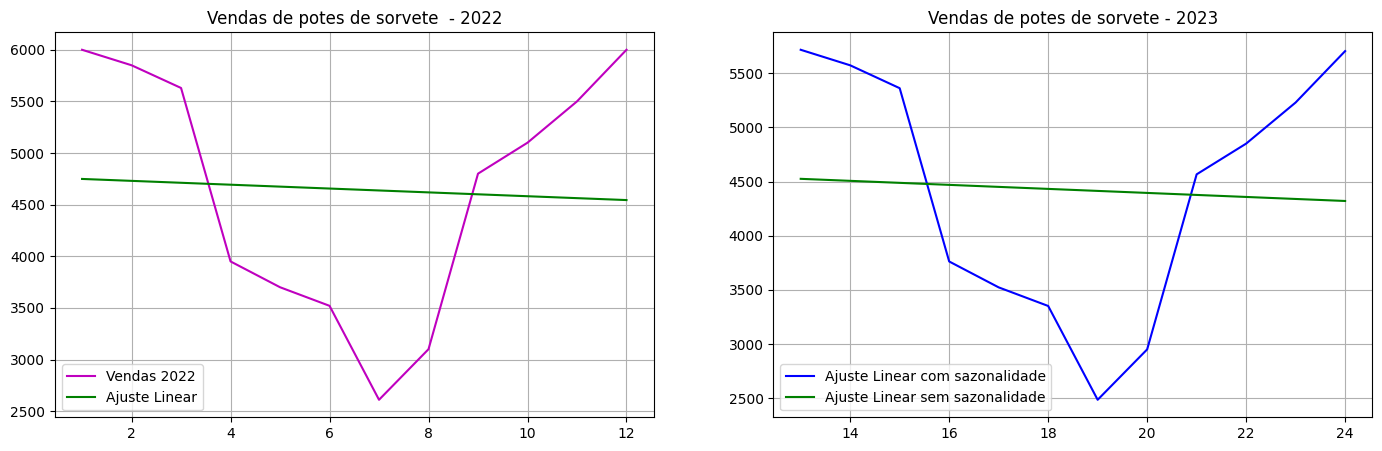

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print()
print("\033[1;34m**\033[0;0m"*40)
print("\33[1;34m*                              Cálculo Numérico                                *\033[0;0m")
print("\033[1;34m*                             Mínimos Quadrados                                *\033[0;0m")

print("\033[1;34m*               Caso Linear - Exemplo: Fábrica de sorvete                      *\033[0;0m")
print("\033[1;34m**\033[0;0m"*40)
print()
print()
x = [1,2,3,4,5,6,7,8,9,10,11,12]
x_futuro = [13,14,15,16,17,18,19,20,21,22,23,24]
y= [6000,   5850,   5630,   3950,   3700,   3520,   2610,   3100,   4800,   5100,   5500,   6000]
meses = ['Janeiro','Fevereiro','Março','Abril','Maio','Junho','Julho','Agosto','Setembro','Outubro','Novembro','Dezembro']
#mês = ["Janeiro   Fevereiro   Março  Abril  Maio  Junho  Julho   Agosto  Setembro  Outubro  Novembro  Dezembro"]

print("\033[1;34mDADOS DO PROBLEMA:\033[0;0m")
print("\33[1;30mMeses: Janeiro  Fevereiro  Março Abril Maio Junho Julho  Agosto Setembro Outubro Novembro Dezembro")
print("Vendas:",y)
print()

print("\033[1;34m**\033[0;0m"*20)
print("\033[1;34m*     Reta dos Mínimos Quadrados       *\033[0;0m")
print("\033[1;34m**\033[0;0m"*20)
print('\033[1;91m\u03D5(x) = ''a\u2080 + a\u2081x\033[0;0m')
print()
print("\033[1;34mSistema Linear\033[0;0m")
print()
print("\033[1;34mMatriz do sistema\033[0;0m")


def MinimosQuadradosLinear(x,y):

  #Somas
  n = len(x)
  x2, xy = [], []
  for j in range(n):
    x2.append(x[j]**2), xy.append(x[j]*y[j])
  soma_x, soma_x2, soma_y, soma_xy = sum(x), sum(x2), sum(y), sum(xy)
  print(' ','{:.0f}'.format(n),'{:.0f}'.format(soma_x))
  print(' ','{:.0f}'.format(soma_x),'{:.0f}'.format(soma_x2))

  #Resolvendo o sistema
  mat = np.array([[n, soma_x],[soma_x,soma_x2]])
  b = np.array([soma_y, soma_xy])
  coefs = np.linalg.solve(mat,b)
  print()
  print("\033[1;34mVetor b \033[0;0m")
  print(' ','{:.0f}'.format(soma_y))
  print(' ','{:.0f}'.format(soma_xy))
  print()
  a0 = coefs[0]
  a1 = coefs[1]
  return a0, a1

def Principal(x,y,x_futuro):

  #Caso linear
  coefs_linear = MinimosQuadradosLinear(x,y)
  print("\033[1;91mSolução: \033[0;0m")
  print('\033[1;91ma\u2080 = \033[0;0m', '{:.7f}'.format(coefs_linear[0]))
  print('\033[1;91ma\u2081 = \033[0;0m', '{:.7f}'.format(coefs_linear[1]))
  print()

  print('\033[1;91m\u03D5(x) =\033[0;0m', '{:.7f}'.format(coefs_linear[0]),'+', '{:.7f}'.format(coefs_linear[1]), 'x ')

  #2022
  print()
  print("\033[1;34mAno de 2022\033[0;0m")
  tab1 = []
  for k in range(len(x)):
    new_y = coefs_linear[1]*x[k] + coefs_linear[0]
    tab1.append([meses[k],y[k],round(new_y)])
  tabela1 = pd.DataFrame(tab1,columns=['2022','Vendas','Ajuste'])
  print(tabela1), print('\n')

  #Índice sazonal
  print("\033[1;34mAno de 2022 - Índice Sazonal Mensal\033[0;0m")
  ind_saz = []
  for k in range(len(tab1)):
    eps = y[k]/tab1[k][-1]
    ind_saz.append([meses[k],round(eps,6)])
  indices = pd.DataFrame(ind_saz,columns=['2022','Épsilon'])
  print(indices), print('\n')

  #2023
  print("\033[1;34mAno de 2023\033[0;0m")
  tab2 = []
  sazonal = []
  for k in range(len(x_futuro)):
    new_y = coefs_linear[1]*x_futuro[k] + coefs_linear[0]
    saz_y = ind_saz[k][1]*new_y
    tab2.append([meses[k],round(new_y),round(saz_y)])
    sazonal.append(saz_y)
  tabela2 = pd.DataFrame(tab2,columns=['2023','Ajuste','Ajuste com correção sazonal'])
  print(tabela2), print('\n')

  #Gráfico 1
  plt.figure(figsize=(17, 5))
  plt.subplot(121)
  plt.figure(1)
  plt.plot(x,y,'m',label='Vendas 2022')
  x_graf = np.linspace(1,12,100)
  y_graf = []
  for elemento in x_graf:
    yy = coefs_linear[1]*elemento + coefs_linear[0]
    y_graf.append(yy)
  plt.plot(x_graf,y_graf,'g',label='Ajuste Linear')
  plt.title('Vendas de potes de sorvete  - 2022')
  plt.grid()
  plt.legend()
  plt.show

  #Gráfico 2
  plt.subplot(122)
  plt.plot(x_futuro,sazonal,'b',label='Ajuste Linear com sazonalidade')
  x_graf = np.linspace(13,24,100)
  y_graf = []
  for elemento in x_graf:
    yy = coefs_linear[1]*elemento + coefs_linear[0]
    y_graf.append(yy)
  plt.plot(x_graf,y_graf,'g',label='Ajuste Linear sem sazonalidade')
  plt.title('Vendas de potes de sorvete - 2023')
  plt.grid()
  plt.legend()
  plt.show

Principal(x,y,x_futuro)

# **Problema 2 - Exemplo: Epidemia**

##Equações de Lotka-Volterra:
##\begin{equation}\left\{\begin{aligned}
& x^\prime  = αx - \beta xy\\
& y^\prime  = - γ  y + \delta xy\\
\end{aligned}\right.
\end{equation}

###Uma aplicação das Equações de Lotka-Volterra é o progresso de uma epidemia de gripe numa população de N indivíduos é modelada pelo seguinte sistema de equações diferenciais:
##\begin{equation}\left\{\begin{aligned}
& x^\prime = - \beta xy\\
& y^\prime  = - α  y + \beta xy\\
\end{aligned}\right.
\end{equation}


###onde x é o número de pessoas suscetíveis de apanhar a gripe e y o número de pessoas infectadas no tempo t.
###Assume-se que não há pessoas inumes e que a população é fixa, logo novos nascimentos são balanceados pelas mortes.

###Os parâmetros $α$, $\beta$ são as taxas de recuperação e transmissão (por dia), respectivamente.



###Sabendo que no instante t$_0$ = 0, os valores de x e y são , respectivamente, 980 e 20, e que $α$ = 0.05 e $\beta$ = 0.0002, avalie a situação da população passados 10 dias do começo da epidemia,  o Método de Euler com h = 0.1



In [ ]:
# Dados iniciais

a = 0.05     # alpha (α)
b = 0.0002   # beta (β)
h = 0.1      # tamanho do salto
t0 = 0       # momento inicial (0 dias)
x0 = 980     # quantidade de pessoas sucetíveis a ficarem gripadas no momento inicial
y0 = 20      # quantidade de pessoas infectadas no momento inicial
t_final = 10 # momento final (10 dias)

# Funções EDO

def fx(x, y):
    return -(b) * (x) * (y)

def fy(x, y):
    return -((a) * (y)) + ((b) * (x) * (y))

# Número de iterações

n = int((t_final - t0) / h)

# Método de Euler

t_atual = t0
xn = x0
yn = y0

for i in range(n):
    xn_1 = xn + ((h) * (fx(xn, yn)))
    yn_1 = yn + ((h) * (fy(xn, yn)))

    # Atualiza os valores
    t_atual += h
    xn = xn_1
    yn = yn_1

print("Situação inicial")
print("Número de pessoas suscetíveis: ", x0)
print("Número de pessoas infectadas: ", y0)

print("\nApós 10 dias:")
print("Número de pessoas suscetíveis: ", xn)
print("Número de pessoas infectadas: ", yn)

Situação inicial
Número de pessoas suscetíveis:  980
Número de pessoas infectadas:  20

Após 10 dias:
Número de pessoas suscetíveis:  898.2032693239028
Número de pessoas infectadas:  80.01864109521915


In [ ]:
A = [1,2,3,4,5,6,7,8,9,10,11,12]
b= [6000,   5850,   5630,   3950,   3700,   3520,   2610,   3100,   4800,   5100,   5500,   6000]

# METODO DE GAUSS PARA SOLUÇÃO
def trianguloSuperior (A):
  k = A[1,0]/A[0,0]
  A[1,0] = A[1,0] -k *A[0,0]
  A[1,1] = A[1,1] -k *A[0,1]
  return A

def solucao (A,b):
  a = []
  al = b[1] / A[1][1]
  a.append(al)
  a0 (b[0] - (A[0][1]*al)) / A[0][0]
  a.insert (0,a0)
  return a

print(a)

NameError: ignored

In [ ]:
# Dados inicias

h = 1 # tamanho do salto
y0 = 2 # quantidade de pessoas que sabem do boato no momento inicial
t0 = 0 # momento inicial (0 horas)
t_final = 4 # momento final (4 horas)

# Funções EDO

def f(y):
  return (2*y*(30-y))/30

# Número de iterações

n = int((t_final - t0) / h)

# Método de Euler

t_atual = t0
yn = y0

for i in range(n+1):
    if i == 0:
      print(f"Número de pessoas que sabem do boato inicialmente: {round(yn)} pessoas")
    elif i == 1:
      print(f"Número de pessoas que sabem do boato após {t_atual} hora: {round(yn)} pessoas")
    else:
      print(f"Número de pessoas que sabem do boato após {t_atual} horas: {round(yn)} pessoas")
    yn_1 = yn + ((h) * (f(yn)))

    # Atualiza os valores
    t_atual += h
    yn = yn_1



Número de pessoas que sabem do boato inicialmente: 2 pessoas
Número de pessoas que sabem do boato após 1 hora: 6 pessoas
Número de pessoas que sabem do boato após 2 horas: 15 pessoas
Número de pessoas que sabem do boato após 3 horas: 30 pessoas
Número de pessoas que sabem do boato após 4 horas: 30 pessoas


In [ ]:
# Dados inicias

h = 1 # tamanho do salto
y0 = 2 # quantidade de pessoas que sabem do boato no momento inicial
t0 = 0 # momento inicial (0 horas)
t_final = 4 # momento final (4 horas)

# Funções EDO

def f(y):
  return (2*y*(30-y))/30

# Número de iterações

n = int((t_final - t0) / h)

# Método de Runge-Kutta 2ª ordem

# yn+1 = yn + h/2 [f(xn, yn) + f(xn+1, y ̄n+1)]

t_atual = t0
yn = y0

for i in range(n+1):
    if i == 0:
      print(f"Número de pessoas que sabem do boato inicialmente: {round(yn)} pessoas")
    elif i == 1:
      print(f"Número de pessoas que sabem do boato após {t_atual} hora: {round(yn)} pessoas")
    else:
      print(f"Número de pessoas que sabem do boato após {t_atual} horas: {round(yn)} pessoas")
    yn1 = yn + (h * (f(yn))) # y ̄n+1 = yn + hf(xn, yn)
    yn_1 = yn + ((h/2)*(f(yn) + f(yn1))) # yn+1 = yn + h/2 [f(xn, yn) + f(xn+1, y ̄n+1)]

    # Atualiza os valores
    t_atual += h
    yn = yn_1


Número de pessoas que sabem do boato inicialmente: 2 pessoas
Número de pessoas que sabem do boato após 1 hora: 9 pessoas
Número de pessoas que sabem do boato após 2 horas: 21 pessoas
Número de pessoas que sabem do boato após 3 horas: 23 pessoas
Número de pessoas que sabem do boato após 4 horas: 24 pessoas


In [ ]:
# Dados inicias

h = 1 # tamanho do salto
y0 = 2 # quantidade de pessoas que sabem do boato no momento inicial
t0 = 0 # momento inicial (0 horas)
t_final = 4 # momento final (4 horas)

# Funções EDO

def f(y):
  return (2*y*(30-y))/30

# Número de iterações

n = int((t_final - t0) / h)

# Método de Runge-Kutta 4ª ordem

# yn+1 = yn + 1/6(k1 + 2k2 + 2k3 + k4)

t_atual = t0
yn = y0

for i in range(n+1):
    if i == 0:
      print(f"Número de pessoas que sabem do boato inicialmente: {round(yn)} pessoas")
    elif i == 1:
      print(f"Número de pessoas que sabem do boato após {t_atual} hora: {round(yn)} pessoas")
    else:
      print(f"Número de pessoas que sabem do boato após {t_atual} horas: {round(yn)} pessoas")
    k1 = h*f(yn) # k1 = hf(yn)
    k2 = h*f(yn + k1/2) # k2 = hf(xn + h/2, yn + k1/2)
    k3 = h*f(yn + k2/2) # k3 = hf(xn + h/2, yn + k2/2)
    k4 = h*f(yn + k3) # k4 = hf(xn + h, yn + k3)
    yn_1 = yn + (1/6)*(k1 + 2*k2 + 2*k3 +k4) # yn+1 = yn + 1/6(k1 + 2k2 + 2k3 + k4)


    # Atualiza os valores
    t_atual += h
    yn = yn_1


Número de pessoas que sabem do boato inicialmente: 2 pessoas
Número de pessoas que sabem do boato após 1 hora: 10 pessoas
Número de pessoas que sabem do boato após 2 horas: 24 pessoas
Número de pessoas que sabem do boato após 3 horas: 28 pessoas
Número de pessoas que sabem do boato após 4 horas: 29 pessoas
